<a href="https://colab.research.google.com/github/LoadBR/Gelt2012502-Processamento-Sinais-1/blob/main/Aula-01/Codigo/AP1_Sinais_e_Sistemas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/LoadBR/Gelt2012502-Processamento-Sinais-1.git


Cloning into 'Gelt2012502-Processamento-Sinais-1'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 39 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 138.74 KiB | 7.71 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [2]:
%cd /content/Gelt2012502-Processamento-Sinais-1

/content/Gelt2012502-Processamento-Sinais-1


In [3]:
!ls

Aula-01  README.md


In [4]:
!ls Aula-01

Codigo	Dados  README.md  Relatorio  Resultados


In [5]:
!ls Aula-01/Dados

handel.wav  h_banheiro.wav  sinal_taca.wav


In [6]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.io import wavfile
from scipy.signal import chirp, resample_poly, fftconvolve
from scipy.fft import fft, fftfreq

from IPython.display import Audio, display

In [7]:
PASTA_DADOS = Path("Aula-01/Dados")
PASTA_RESULTADOS = Path("Aula-01/Resultados")

print("Pasta de dados:", PASTA_DADOS)
print("Pasta de resultados:", PASTA_RESULTADOS)

Pasta de dados: Aula-01/Dados
Pasta de resultados: Aula-01/Resultados


In [8]:
fs = 44100
duracao = 0.5
f = 500

t = np.arange(0, duracao, 1/fs)
x = np.cos(2 * np.pi * f * t)

print("Frequência de amostragem:", fs, "Hz")
print("Duração:", duracao, "s")
print("Frequência do sinal:", f, "Hz")
print("Número de amostras:", len(x))

Frequência de amostragem: 44100 Hz
Duração: 0.5 s
Frequência do sinal: 500 Hz
Número de amostras: 22050


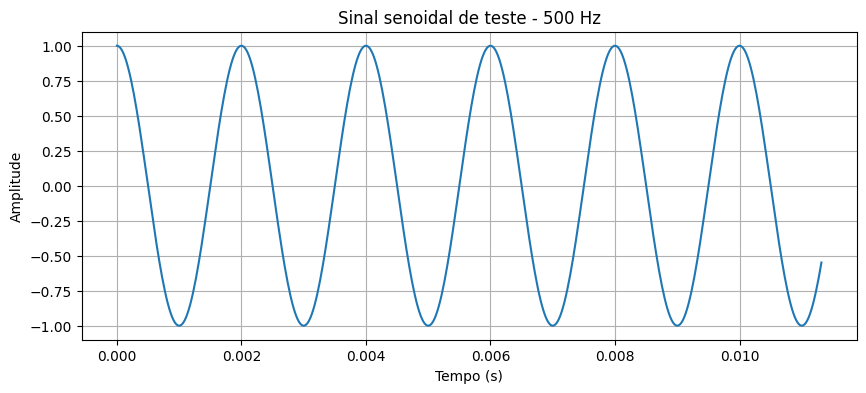

In [10]:
plt.figure(figsize=(10, 4))

plt.plot(t[:500], x[:500])

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("Sinal senoidal de teste - 500 Hz")
plt.grid()

plt.show()


In [11]:
display(Audio(x, rate=fs))


# Questão 1 — Sinais senoidais

Geração, visualização e reprodução de sinais senoidais de 500 Hz, 5 kHz e 10 kHz, com frequência de amostragem de 44,1 kHz e duração de 5 segundos.

In [12]:
# Parâmetros da Questão 1
fs = 44100              # Frequência de amostragem em Hz
duracao = 5             # Duração do sinal em segundos
frequencias = [500, 5000, 10000]

# Vetor de tempo
t = np.arange(0, duracao, 1/fs)

print("Frequência de amostragem:", fs, "Hz")
print("Duração:", duracao, "s")
print("Número de amostras:", len(t))
print("Frequências analisadas:", frequencias, "Hz")

Frequência de amostragem: 44100 Hz
Duração: 5 s
Número de amostras: 220500
Frequências analisadas: [500, 5000, 10000] Hz


In [13]:
# Geração dos sinais senoidais
sinais = {}

for f in frequencias:
    sinais[f] = np.cos(2 * np.pi * f * t)

print("Sinais gerados:")
for f in frequencias:
    print(f"{f} Hz -> {len(sinais[f])} amostras")

Sinais gerados:
500 Hz -> 220500 amostras
5000 Hz -> 220500 amostras
10000 Hz -> 220500 amostras


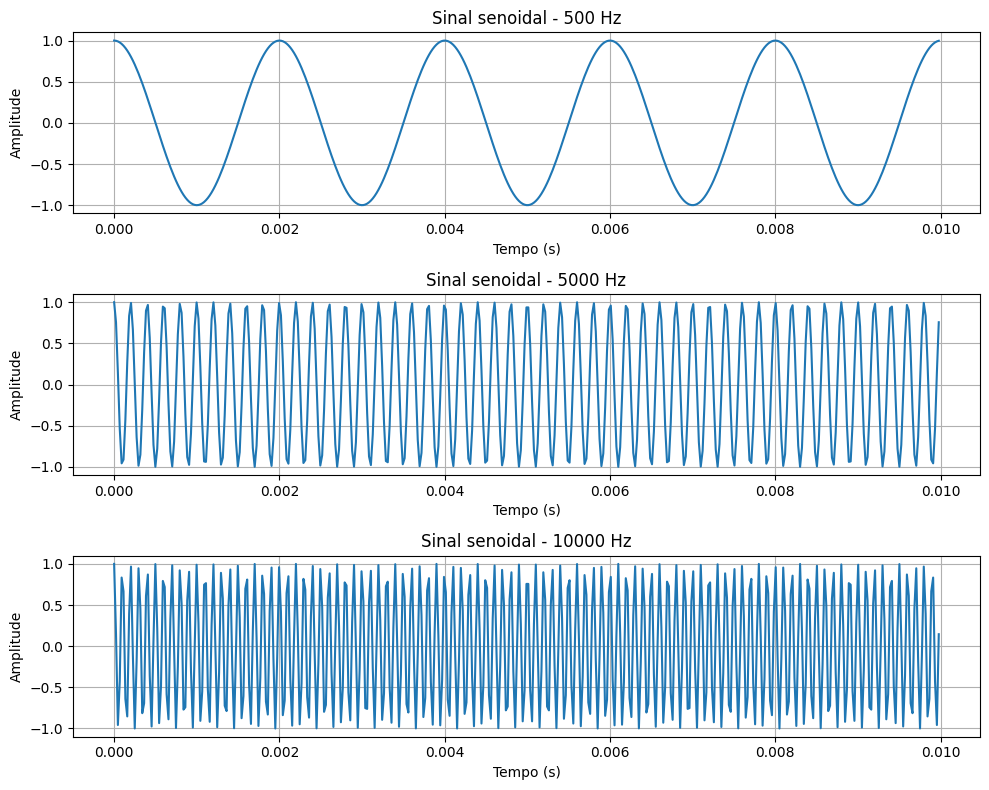

In [16]:
# Visualização dos primeiros 10 ms de cada sinal

tempo_zoom = 0.01
n_zoom = int(fs * tempo_zoom)

plt.figure(figsize=(10, 8))

for i, f in enumerate(frequencias, start=1):
    plt.subplot(3, 1, i)
    plt.plot(t[:n_zoom], sinais[f][:n_zoom])
    plt.title(f"Sinal senoidal - {f} Hz")
    plt.xlabel("Tempo (s)")
    plt.ylabel("Amplitude")
    plt.grid()

plt.tight_layout()
plt.savefig(
    PASTA_RESULTADOS / "q1_sinais_senoidais.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [17]:
!ls Aula-01/Resultados

q1_sinais_senoidais.png


In [15]:
# Reprodução dos sinais senoidais

for f in frequencias:
    print(f"Sinal de {f} Hz:")
    display(Audio(sinais[f], rate=fs))

Sinal de 500 Hz:


Sinal de 5000 Hz:


Sinal de 10000 Hz:


### Comentários dos resultados


Na reprodução dos sinais, percebe-se que o aumento da frequência produz tons progressivamente mais agudos.

O sinal de 500 Hz apresenta um tom relativamente grave quando comparado aos sinais de 5 kHz e 10 kHz.

Os três sinais apresentam a mesma amplitude e duração, diferindo apenas em sua frequência.

No intervalo de 10 ms utilizado para visualização, observa-se que o sinal de 500 Hz apresenta aproximadamente 5 ciclos, enquanto os sinais de 5 kHz e 10 kHz apresentam aproximadamente 50 e 100 ciclos, respectivamente.

Esse comportamento é consistente com a relação entre frequência e período, dada por $T = 1/f$.

Para a frequência de amostragem de 44,1 kHz, a frequência de Nyquist é de 22,05 kHz. Portanto, as três frequências analisadas estão abaixo desse limite e podem ser representadas sem ocorrência de aliasing devido à amostragem.

No gráfico do sinal de 10 kHz, a forma de onda apresenta visualmente menos pontos por período do que nos sinais de menor frequência.

Isso ocorre porque, com uma frequência de amostragem de 44,1 kHz, existem aproximadamente 4,41 amostras por período para o sinal de 10 kHz, enquanto o sinal de 500 Hz possui aproximadamente 88,2 amostras por período.

# Questão 2 — Chirps

Geração, visualização e reprodução de sinais chirp com frequências variando de 500 Hz a 10 kHz ao longo de 5 segundos, utilizando varreduras linear, quadrática e logarítmica.

In [18]:
# Parâmetros da Questão 2
fs_chirp = 44100
duracao_chirp = 5
f0 = 500
f1 = 10000

t_chirp = np.arange(0, duracao_chirp, 1/fs_chirp)

print("Frequência de amostragem:", fs_chirp, "Hz")
print("Duração:", duracao_chirp, "s")
print("Frequência inicial:", f0, "Hz")
print("Frequência final:", f1, "Hz")
print("Número de amostras:", len(t_chirp))

Frequência de amostragem: 44100 Hz
Duração: 5 s
Frequência inicial: 500 Hz
Frequência final: 10000 Hz
Número de amostras: 220500


In [21]:
# Geração dos chirps

chirp_linear = chirp(
    t_chirp,
    f0=f0,
    f1=f1,
    t1=duracao_chirp,
    method="linear"
)

chirp_quadratico = chirp(
    t_chirp,
    f0=f0,
    f1=f1,
    t1=duracao_chirp,
    method="quadratic",
    vertex_zero=True
)

chirp_logaritmico = chirp(
    t_chirp,
    f0=f0,
    f1=f1,
    t1=duracao_chirp,
    method="logarithmic"
)

print("Chirps gerados com sucesso.")
print("Linear:", len(chirp_linear), "amostras")
print("Quadrático:", len(chirp_quadratico), "amostras")
print("Logarítmico:", len(chirp_logaritmico), "amostras")

Chirps gerados com sucesso.
Linear: 220500 amostras
Quadrático: 220500 amostras
Logarítmico: 220500 amostras


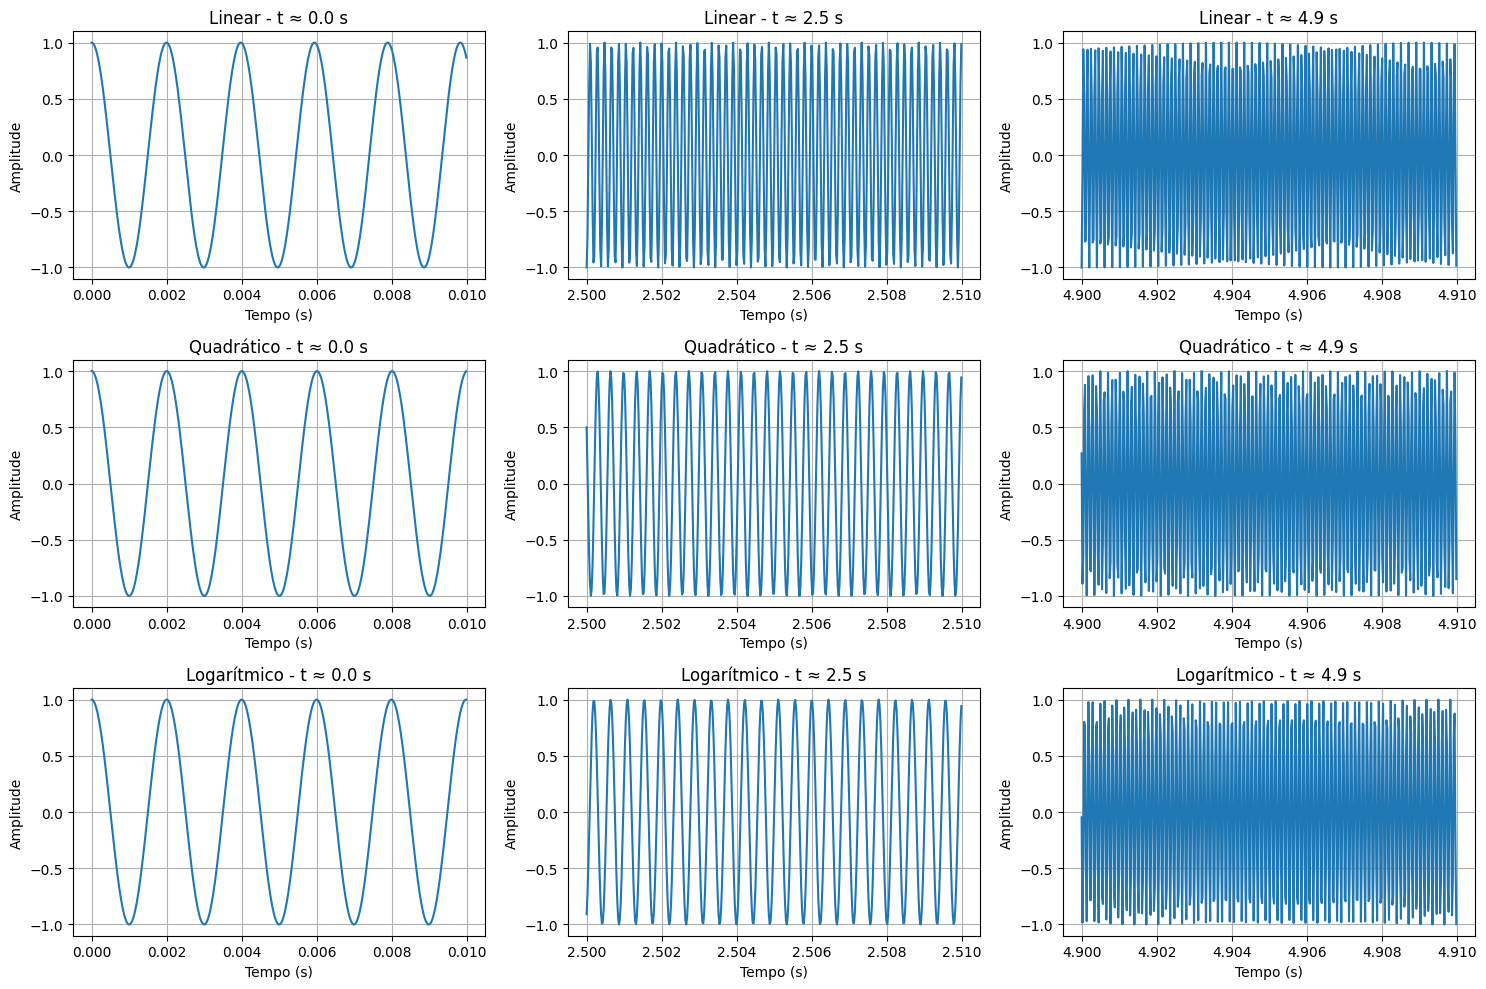

In [23]:
# Organização dos chirps para visualização
chirps = {
    "Linear": chirp_linear,
    "Quadrático": chirp_quadratico,
    "Logarítmico": chirp_logaritmico
}

# Instantes escolhidos para comparação
instantes = [0.0, 2.5, 4.9]   # início, meio e final
janela = 0.01                 # 10 ms

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for linha, (nome, sinal) in enumerate(chirps.items()):

    for coluna, instante in enumerate(instantes):

        inicio = int(instante * fs_chirp)
        fim = inicio + int(janela * fs_chirp)

        axes[linha, coluna].plot(
            t_chirp[inicio:fim],
            sinal[inicio:fim]
        )

        axes[linha, coluna].set_title(
            f"{nome} - t ≈ {instante:.1f} s"
        )

        axes[linha, coluna].set_xlabel("Tempo (s)")
        axes[linha, coluna].set_ylabel("Amplitude")
        axes[linha, coluna].grid()

plt.tight_layout()
plt.savefig(
    PASTA_RESULTADOS / "q2_chirps_tempo.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [24]:
!ls Aula-01/Resultados

q1_sinais_senoidais.png  q2_chirps_tempo.png


In [25]:
# Reprodução dos chirps

print("Chirp linear:")
display(Audio(chirp_linear, rate=fs_chirp))

print("Chirp quadrático:")
display(Audio(chirp_quadratico, rate=fs_chirp))

print("Chirp logarítmico:")
display(Audio(chirp_logaritmico, rate=fs_chirp))

Chirp linear:


Chirp quadrático:


Chirp logarítmico:


### Comentários dos resultados

Os três chirps possuem a mesma duração, frequência inicial de 500 Hz e frequência final de 10 kHz.

A diferença entre eles está na forma como a frequência instantânea varia ao longo do tempo.

No chirp linear, a frequência aumenta a uma taxa constante. Por isso, no instante intermediário do sinal, em torno de 2,5 s, a frequência já se encontra aproximadamente no valor médio entre as frequências inicial e final.

No chirp quadrático, utilizando `vertex_zero=True`, a frequência aumenta mais lentamente no início e mais rapidamente próximo ao final. Dessa forma, na metade da duração do sinal, sua frequência instantânea é menor que a do chirp linear.

No chirp logarítmico, a frequência varia de forma exponencial ao longo do tempo. Assim, a varredura permanece proporcionalmente mais tempo nas frequências mais baixas e aumenta progressivamente sua taxa de variação em direção às frequências mais altas.

Essa diferença também pode ser observada nos gráficos. No início, os três sinais apresentam comportamento semelhante, pois todos partem de 500 Hz.

Em torno de 2,5 s, o chirp linear apresenta maior densidade de oscilações, seguido pelo quadrático e pelo logarítmico. Próximo ao final dos 5 s, os três sinais se aproximam de 10 kHz e apresentam elevada densidade de oscilações.

Na reprodução dos sinais, as três varreduras são percebidas como sons que evoluem de frequências mais baixas para mais altas, porém com velocidades de mudança distintas ao longo do tempo.

# Questão 3 — Análise do sinal `handel.wav`

Leitura, visualização, reprodução em diferentes frequências de amostragem e análise espectral do sinal de áudio `handel.wav`.

In [26]:
# Leitura do arquivo handel.wav

caminho_handel = PASTA_DADOS / "handel.wav"

fs_handel, handel = wavfile.read(caminho_handel)

print("Frequência de amostragem original:", fs_handel, "Hz")
print("Número de amostras:", len(handel))
print("Formato dos dados:", handel.shape)
print("Tipo dos dados:", handel.dtype)

Frequência de amostragem original: 8192 Hz
Número de amostras: 73113
Formato dos dados: (73113,)
Tipo dos dados: int16


In [27]:
# Vetor de tempo e duração do sinal handel.wav

duracao_handel = len(handel) / fs_handel
t_handel = np.arange(len(handel)) / fs_handel

print(f"Duração do sinal: {duracao_handel:.2f} s")

Duração do sinal: 8.92 s


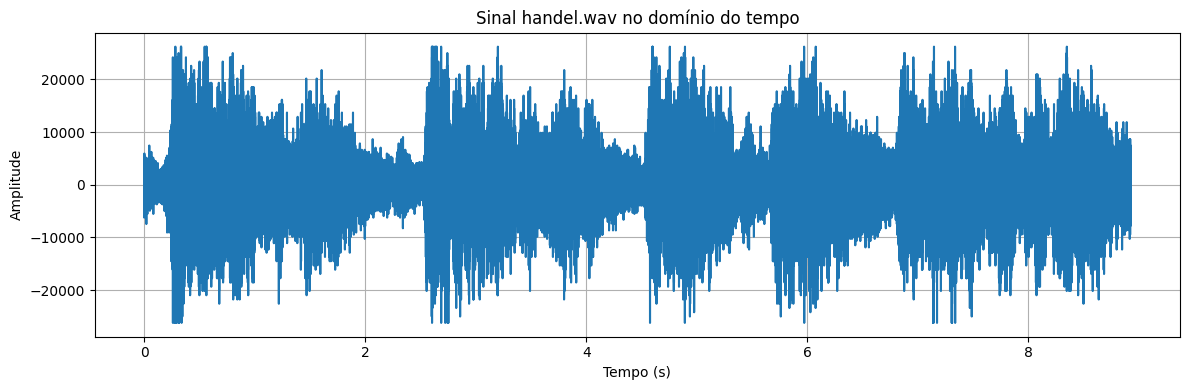

In [28]:
# Sinal handel.wav no domínio do tempo

plt.figure(figsize=(12, 4))

plt.plot(t_handel, handel)

plt.title("Sinal handel.wav no domínio do tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()

plt.tight_layout()

plt.savefig(
    PASTA_RESULTADOS / "q3_handel_tempo.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
!ls Aula-01/Resultados

q1_sinais_senoidais.png  q2_chirps_tempo.png  q3_handel_tempo.png


In [30]:
# Reprodução do sinal handel.wav em diferentes frequências de amostragem

print(f"Frequência original: {fs_handel} Hz")
display(Audio(handel, rate=fs_handel))

print(f"Dobro da frequência original: {2 * fs_handel} Hz")
display(Audio(handel, rate=2 * fs_handel))

print(f"Quádruplo da frequência original: {4 * fs_handel} Hz")
display(Audio(handel, rate=4 * fs_handel))

Frequência original: 8192 Hz


Dobro da frequência original: 16384 Hz


Quádruplo da frequência original: 32768 Hz


In [31]:
# Cálculo do espectro do sinal handel.wav

N_handel = len(handel)

espectro_handel = np.fft.rfft(handel)
frequencias_handel = np.fft.rfftfreq(N_handel, d=1/fs_handel)

magnitude_handel = np.abs(espectro_handel) / N_handel

# Normalização para facilitar a visualização
magnitude_handel_norm = magnitude_handel / np.max(magnitude_handel)

print("Frequência máxima do espectro:", frequencias_handel[-1], "Hz")

Frequência máxima do espectro: 4095.9439771312896 Hz


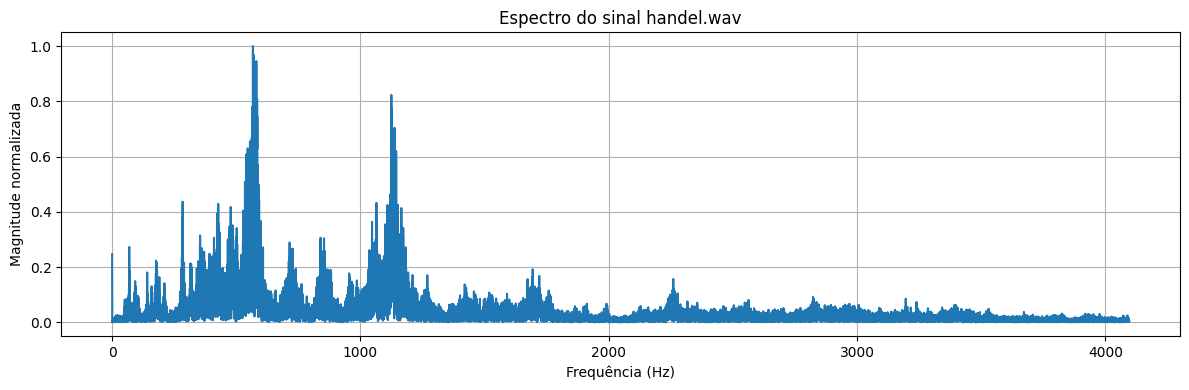

In [32]:
# Espectro do sinal handel.wav

plt.figure(figsize=(12, 4))

plt.plot(frequencias_handel, magnitude_handel_norm)

plt.title("Espectro do sinal handel.wav")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude normalizada")
plt.grid()

plt.tight_layout()

plt.savefig(
    PASTA_RESULTADOS / "q3_handel_espectro.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

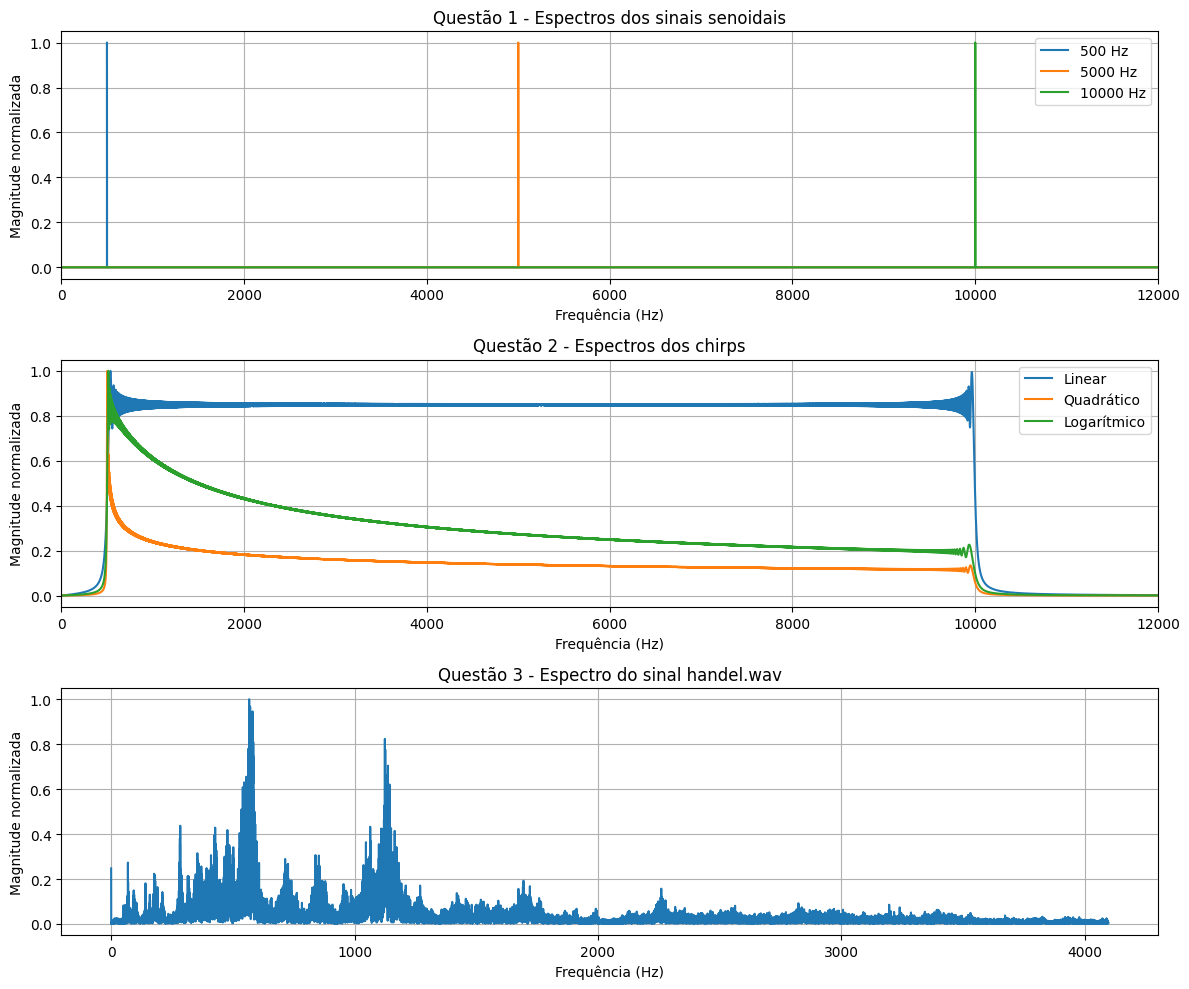

In [33]:
# Comparação dos espectros das Questões 1, 2 e 3

# ---------- Questão 1: senóides ----------
freq_q1 = np.fft.rfftfreq(len(t), d=1/fs)

espectros_q1 = {}

for f in frequencias:
    magnitude = np.abs(np.fft.rfft(sinais[f]))
    espectros_q1[f] = magnitude / np.max(magnitude)


# ---------- Questão 2: chirps ----------
freq_q2 = np.fft.rfftfreq(len(t_chirp), d=1/fs_chirp)

espectros_q2 = {}

for nome, sinal in chirps.items():
    magnitude = np.abs(np.fft.rfft(sinal))
    espectros_q2[nome] = magnitude / np.max(magnitude)


# ---------- Gráficos ----------
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Questão 1
for f in frequencias:
    axes[0].plot(freq_q1, espectros_q1[f], label=f"{f} Hz")

axes[0].set_title("Questão 1 - Espectros dos sinais senoidais")
axes[0].set_xlim(0, 12000)
axes[0].set_xlabel("Frequência (Hz)")
axes[0].set_ylabel("Magnitude normalizada")
axes[0].legend()
axes[0].grid()


# Questão 2
for nome in chirps:
    axes[1].plot(freq_q2, espectros_q2[nome], label=nome)

axes[1].set_title("Questão 2 - Espectros dos chirps")
axes[1].set_xlim(0, 12000)
axes[1].set_xlabel("Frequência (Hz)")
axes[1].set_ylabel("Magnitude normalizada")
axes[1].legend()
axes[1].grid()


# Questão 3
axes[2].plot(frequencias_handel, magnitude_handel_norm)

axes[2].set_title("Questão 3 - Espectro do sinal handel.wav")
axes[2].set_xlabel("Frequência (Hz)")
axes[2].set_ylabel("Magnitude normalizada")
axes[2].grid()


plt.tight_layout()

plt.savefig(
    PASTA_RESULTADOS / "q3_comparacao_espectros.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Comentários dos resultados

O arquivo `handel.wav` possui frequência de amostragem original de 8192 Hz, 73113 amostras e duração aproximada de 8,92 s.

O sinal é mono e apresenta uma forma de onda temporal consideravelmente mais complexa do que os sinais sintéticos das questões anteriores.

Ao reproduzir as mesmas amostras utilizando a frequência de amostragem original, o dobro e o quádruplo desse valor, observou-se uma redução progressiva da duração do áudio e um aumento da altura percebida do som.

No domínio da frequência, as senoides da Questão 1 apresentam espectros concentrados em frequências específicas, com picos em 500 Hz, 5 kHz e 10 kHz. Esse comportamento é característico de sinais senoidais puros.

Os chirps da Questão 2, por outro lado, apresentam componentes distribuídas aproximadamente entre 500 Hz e 10 kHz, pois suas frequências instantâneas variam continuamente ao longo do tempo.

A distribuição espectral também depende do tipo de varredura utilizado. O chirp linear apresenta uma distribuição relativamente mais uniforme ao longo da faixa percorrida, enquanto os chirps quadrático e logarítmico apresentam distribuições não uniformes devido às diferentes taxas de variação da frequência.

O sinal `handel.wav` apresenta um espectro mais complexo, contendo diversas componentes de frequência simultâneas.

Observam-se vários picos e regiões de maior concentração espectral, característica esperada para um sinal musical composto por diferentes notas, harmônicos e variações temporais.

Como sua frequência de amostragem é 8192 Hz, a maior frequência representável é limitada pela frequência de Nyquist, correspondente a 4096 Hz.

Os espectros apresentados foram normalizados individualmente pelo respectivo valor máximo. Dessa forma, a comparação realizada enfatiza a distribuição relativa das componentes de frequência de cada sinal, e não suas amplitudes absolutas.

In [34]:
!ls Aula-01/Resultados

q1_sinais_senoidais.png  q3_comparacao_espectros.png  q3_handel_tempo.png
q2_chirps_tempo.png	 q3_handel_espectro.png
